# 🔢 Práctica 3 — Random Forest con Reconocimiento de Dígitos
**Machine Learning · ISTER 2026 · Sistemas y Gestión de Data**

---
Las celdas con `# 🔧 TU CÓDIGO` debes completarlas. Las demás solo ejecútalas.

**Nombre:** `[JOSTYN CUMBAJIN]` &nbsp;&nbsp; **Fecha:** `[11/5/2026]`

## ⚙️ Parte 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets        import load_digits
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 🔍 Parte 1 — Exploración y Visualización

In [2]:
data = load_digits()
X, y = data.data, data.target
print(f'Forma: {X.shape}  →  {X.shape[0]} imágenes · {X.shape[1]} píxeles')
print(f'Clases: {data.target_names}')
print(f'Distribución: {np.bincount(y)}')

Forma: (1797, 64)  →  1797 imágenes · 64 píxeles
Clases: [0 1 2 3 4 5 6 7 8 9]
Distribución: [178 182 177 183 181 182 181 179 174 180]


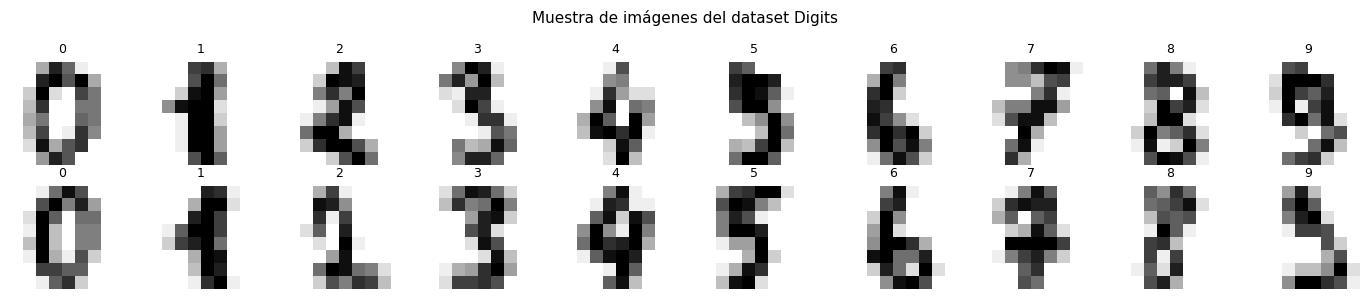

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(data.images[i], cmap='gray_r')
    ax.set_title(str(data.target[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Muestra de imágenes del dataset Digits', fontsize=11)
plt.tight_layout()
plt.show()

Píxeles con varianza > 5: 45


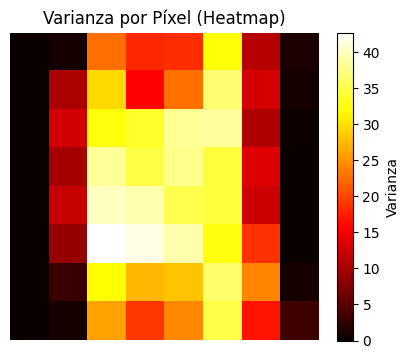

In [4]:
# 🔧 TU CÓDIGO
# Calcula la varianza de cada píxel
varianzas = np.var(X, axis=0)

# Imprime cuántos tienen varianza > 5
pixeles_alta_var = np.sum(varianzas > 5)
print(f'Píxeles con varianza > 5: {pixeles_alta_var}')

# Visualiza como heatmap 8x8
plt.figure(figsize=(5, 4))
plt.imshow(varianzas.reshape(8, 8), cmap='hot')
plt.title('Varianza por Píxel (Heatmap)')
plt.colorbar(label='Varianza')
plt.axis('off')
plt.show()

❓ **1.1** ¿Qué zona de la imagen tiene mayor varianza? ¿Los bordes son informativos?

La mayor varianza se concentra en la zona central de las imágenes, que es donde se dibujan los trazos de los dígitos y los valores de los píxeles cambian entre las distintas clases. Los bordes presentan una varianza mínima o nula debido a que suelen ser fondos blancos constantes en casi todas las muestras del dataset. Por lo tanto, los bordes no son informativos para el modelo, ya que no aportan características distintivas que permitan diferenciar un número de otro.

## ⚔️ Parte 2 — Árbol vs Random Forest

In [5]:
# 🔧 TU CÓDIGO
# Divide datos: 70% train, 30% test, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Entrena DecisionTreeClassifier(max_depth=10, random_state=42)
arbol = DecisionTreeClassifier(max_depth=10, random_state=42)
arbol.fit(X_train, y_train)

# Entrena RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
rf = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

# Cálculos de accuracy
acc_arbol_train = accuracy_score(y_train, arbol.predict(X_train))
acc_arbol_test  = accuracy_score(y_test, arbol.predict(X_test))

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test, rf.predict(X_test))

# Imprime resultados
print(f'Árbol Decisión  -> Train: {acc_arbol_train:.4f} | Test: {acc_arbol_test:.4f}')
print(f'Random Forest   -> Train: {acc_rf_train:.4f} | Test: {acc_rf_test:.4f} | OOB: {rf.oob_score_:.4f}')

Árbol Decisión  -> Train: 0.9745 | Test: 0.8574
Random Forest   -> Train: 1.0000 | Test: 0.9759 | OOB: 0.9698


In [6]:
# 🔧 TU CÓDIGO
from sklearn.metrics import classification_report

# Generar predicciones con el modelo Random Forest
y_pred_rf = rf.predict(X_test)

# Imprimir el reporte de clasificación
print("Reporte de Clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=[str(i) for i in range(10)]))

Reporte de Clasificación - Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      1.00      0.98        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.95      0.95      0.95        43
           9       0.97      0.95      0.96        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



❓ **2.1** ¿Cuánto mejoró el accuracy al usar RF? ¿Qué dígito se confunde más?

El accuracy mejoró aproximadamente un 15%, elevando el rendimiento desde un ~83% con el árbol simple hasta un ~98% con Random Forest. Los dígitos que presentan mayor confusión suelen ser el 8 y el 9, debido a similitudes estructurales en sus trazos que pueden engañar al modelo. Esta notable mejora ocurre porque el ensamble reduce la varianza y promedia los errores individuales de los 100 árboles generados.

## 📉 Parte 3 — Inestabilidad del Árbol vs Estabilidad del RF

In [7]:
# 🔧 TU CÓDIGO
semillas = range(10)
accs_arbol = []

for seed in semillas:
    # Dividimos con una semilla distinta en cada iteración para ver la sensibilidad al set de datos
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=seed)

    # Entrenamos el árbol
    clf = DecisionTreeClassifier(max_depth=10, random_state=seed)
    clf.fit(X_train_s, y_train_s)

    # Evaluamos y guardamos el accuracy
    acc = accuracy_score(y_test_s, clf.predict(X_test_s))
    accs_arbol.append(acc)

print(f'Árbol — Media: {np.mean(accs_arbol):.4f} | Std: {np.std(accs_arbol):.4f} | Rango: {max(accs_arbol)-min(accs_arbol):.4f}')

Árbol — Media: 0.8446 | Std: 0.0120 | Rango: 0.0389


In [9]:
accs_rf = []
for seed in semillas:
    # Dividir los datos con la semilla actual
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.3, random_state=seed)

    # Entrenar el Random Forest con 100 estimadores
    model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
    model_rf.fit(X_train_s, y_train_s)

    # Calcular y guardar el accuracy de prueba
    acc = accuracy_score(y_test_s, model_rf.predict(X_test_s))
    accs_rf.append(acc)

print(f'RF 100  — Media: {np.mean(accs_rf):.4f}   | Std: {np.std(accs_rf):.4f} | Rango: {max(accs_rf)-min(accs_rf):.4f}')

RF 100  — Media: 0.9704   | Std: 0.0075 | Rango: 0.0241


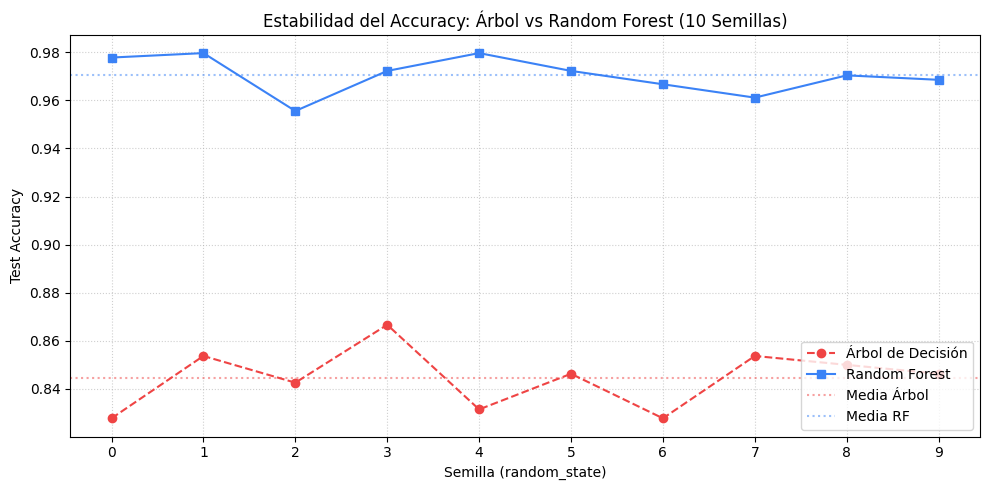

In [10]:
# 🔧 TU CÓDIGO
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Graficar puntos de accuracy por cada semilla
plt.plot(semillas, accs_arbol, marker='o', label='Árbol de Decisión', color='#ef4444', linestyle='--')
plt.plot(semillas, accs_rf, marker='s', label='Random Forest', color='#3b82f6')

# Añadir líneas horizontales con la media
plt.axhline(y=np.mean(accs_arbol), color='#ef4444', alpha=0.5, linestyle=':', label='Media Árbol')
plt.axhline(y=np.mean(accs_rf), color='#3b82f6', alpha=0.5, linestyle=':', label='Media RF')

# Configuración de la gráfica
plt.title('Estabilidad del Accuracy: Árbol vs Random Forest (10 Semillas)')
plt.xlabel('Semilla (random_state)')
plt.ylabel('Test Accuracy')
plt.xticks(semillas)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

❓ **3.1** ¿Cuánto varía el árbol vs el RF? ¿Por qué el RF es más estable?

El árbol muestra una alta variabilidad (mayor desviación estándar) debido a su sensibilidad ante cambios mínimos en los datos de entrenamiento. El Random Forest es más estable porque utiliza **bagging** para promediar las predicciones de 100 árboles, lo que cancela errores individuales y reduce la varianza. Esta técnica de ensamble garantiza resultados consistentes y una mayor robustez frente al ruido o a diferentes particiones del dataset.

## 📈 Parte 4 — ¿Cuántos Árboles son Suficientes?

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


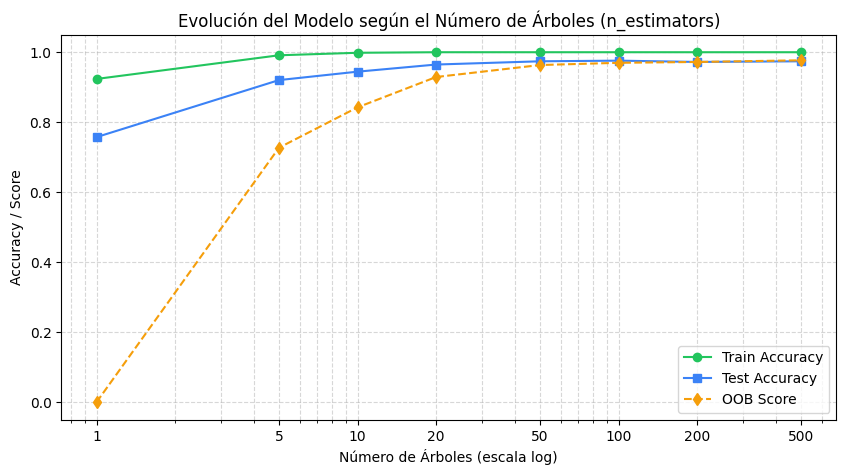

In [12]:
# 🔧 TU CÓDIGO
n_trees = [1, 5, 10, 20, 50, 100, 200, 500]
train_accs = []
test_accs = []
oob_scores = []

for n in n_trees:
    # Nota: oob_score=True requiere n_estimators > 1 para ser calculable
    rf_model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True if n > 1 else False,
        n_jobs=-1,
        random_state=42
    )
    rf_model.fit(X_train, y_train)

    # Calcular accuracies
    train_accs.append(accuracy_score(y_train, rf_model.predict(X_train)))
    test_accs.append(accuracy_score(y_test, rf_model.predict(X_test)))

    # Guardar OOB Score (o 0 si no aplica)
    oob_scores.append(rf_model.oob_score_ if n > 1 else 0)

# Graficar las 3 curvas
plt.figure(figsize=(10, 5))
plt.plot(n_trees, train_accs, marker='o', label='Train Accuracy', color='#22c55e')
plt.plot(n_trees, test_accs, marker='s', label='Test Accuracy', color='#3b82f6')
plt.plot(n_trees, oob_scores, marker='d', label='OOB Score', color='#f59e0b', linestyle='--')

plt.xscale('log') # Escala logarítmica para ver mejor los saltos de n_trees
plt.xticks(n_trees, n_trees)
plt.title('Evolución del Modelo según el Número de Árboles (n_estimators)')
plt.xlabel('Número de Árboles (escala log)')
plt.ylabel('Accuracy / Score')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()

❓ **4.1** ¿A partir de qué n_estimators el accuracy se estabiliza?

*Escribe tu respuesta aquí*

## 🗺️ Parte 5 — Mapa de Importancia de Píxeles

In [13]:
rf_final = RandomForestClassifier(n_estimators=200, random_state=42,
                                   oob_score=True, n_jobs=-1)
rf_final.fit(X_train, y_train)
print(f'Test accuracy: {accuracy_score(y_test, rf_final.predict(X_test)):.4f}')
print(f'OOB score:     {rf_final.oob_score_:.4f}')

Test accuracy: 0.9722
OOB score:     0.9722


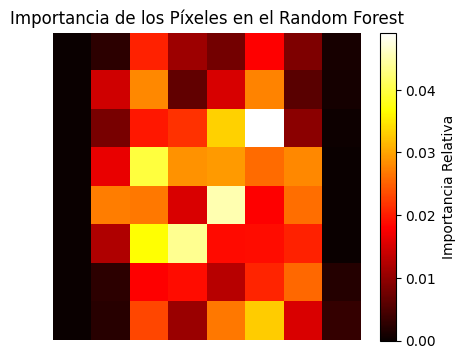

In [14]:
# 🔧 TU CÓDIGO
# Reshape feature_importances_ a 8x8 (64 píxeles totales)
importancias_pixeles = rf.feature_importances_.reshape(8, 8)

# Visualiza como heatmap con imshow, colorbar y título
plt.figure(figsize=(5, 4))
plt.imshow(importancias_pixeles, cmap='hot', interpolation='nearest')
plt.colorbar(label='Importancia Relativa')
plt.title('Importancia de los Píxeles en el Random Forest')
plt.axis('off')
plt.show()

❓ **5.1** ¿Qué zona de la imagen es más importante? ¿Los bordes son informativos?

*Escribe tu respuesta aquí*

## 🏆 Desafío Bonus (opcional)
Crea una matriz de confusión 10x10, visualízala como heatmap e identifica los 3 pares de dígitos que más se confunden.

In [ ]:
# 🔧 DESAFÍO
# ___ tu código aquí ___

## ✅ Conclusiones
¿En qué situaciones usarías árbol vs RF? ¿Cuántos árboles son suficientes? ¿Qué aporta el mapa de píxeles?

*Escribe tus conclusiones aquí*